# 📊 Modèle de Fit de Dose - Skyshine Enhanced

Ce notebook contient **deux modèles optimaux** pour fitter les données de dose en fonction de la distance et de l'épaisseur d'écran.

**Modèles disponibles** :
- 🔵 **Modèle Simple** (4 paramètres) : Recommandé pour les **neutrons**
- 🟢 **Modèle Skyshine Enhanced** (9 paramètres) : Optimal pour les **photons**

---

## 📋 Contenu
1. Chargement des données depuis la base de données Excel
2. **Modèle Simple** - Pour neutrons (4 paramètres)
3. **Modèle Skyshine Enhanced** - Pour photons (9 paramètres)
4. Application des modèles et visualisation
5. Export des paramètres optimaux

## 1️⃣ Imports et Configuration

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import curve_fit

# Import des fonctions utilitaires (depuis DB_fit.ipynb)
sys.path.append('../utils')
from plot_func_notebook import create_filter_plot, plot_categorical_bar_chart, plot_ratio_by_configurations, filter_wall_df
from utils_func_notebook import fit_data_to_distance, fit_data_to_distance_thickness

# Configuration matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print("✅ Imports réussis")

✅ Imports réussis


## 2️⃣ Chargement des Données

Utilisation de la même méthode que dans `DB_fit.ipynb` pour la cohérence.

In [2]:
# Chargement des données depuis la base de données Excel
data = pd.read_excel("../Database/All-at-once_DB.xlsx", sheet_name='wall')

# Configuration du filtrage (modifiable selon vos besoins)
particles = ['N']  # 'P' pour photons, 'N' pour neutrons
screens = ['Concrete']  # 'Lead', 'Concrete', 'Steel', 'Water'
cases = ['C1 [U(4.95)O2F2 (H/235U = 410)]']
codes = ['MCNP 6.1']  # 'MCNP 6.1', 'COG 11.2', 'SCALE 6.2.2'
thicknesses = []  # [] = toutes les épaisseurs, ou [1, 5, 10, 20] pour filtrer

# Filtrage des données
data_filtered = filter_wall_df(data, particles, screens, cases, codes, thicknesses)

# Extraction des colonnes pour le fit
r_data = data_filtered['Distance (m)'].values
T_data = data_filtered['Thickness (cm)'].values
D_data = data_filtered['Dose (Gy)'].values

print(f"✅ Données chargées : {len(data_filtered)} points")
print(f"   • Particule  : {particles[0]}")
print(f"   • Écran      : {screens[0]}")
print(f"   • Distance   : {r_data.min():.0f} - {r_data.max():.0f} m")
print(f"   • Épaisseur  : {T_data.min():.0f} - {T_data.max():.0f} cm")
print(f"   • Dose       : {D_data.min():.2e} - {D_data.max():.2e} Gy")

✅ Données chargées : 26 points
   • Particule  : N
   • Écran      : Concrete
   • Distance   : 1 - 1200 m
   • Épaisseur  : 20 - 40 cm
   • Dose       : 1.45e-09 - 2.46e+00 Gy


---

## 3️⃣ Modèle Simple (Neutrons)

### 📐 Équation du modèle

Le **Modèle Simple** est basé sur une loi de propagation avec atténuation :

$$
D(r, T) = A \cdot r^{-k} \cdot e^{-b \cdot r} \cdot e^{-c \cdot T}
$$

où :
- **A** : Amplitude (intensité de la source)
- **k** : Exposant de décroissance géométrique (typiquement ~2 pour inverse carré)
- **b** : Coefficient d'atténuation dans l'air (m⁻¹)
- **c** : Coefficient d'atténuation dans l'écran (cm⁻¹)

### 🔧 Paramètres du modèle (4)

| Paramètre | Description | Unité |
|-----------|-------------|-------|
| `A` | Amplitude source | - |
| `k` | Exposant géométrique | - |
| `b` | Coefficient d'atténuation air | m⁻¹ |
| `c` | Coefficient d'atténuation écran | cm⁻¹ |

**Avantages** : Moins de paramètres, plus robuste pour les neutrons (pas d'effet skyshine significatif)

In [3]:
def fit_simple_model(r_data, T_data, D_data, plot=True, verbose=True):
    """
    Ajuste le modèle simple aux données de dose (recommandé pour neutrons).
    
    Modèle : D = A × r^(-k) × exp(-b×r) × exp(-c×T)
    
    Parameters:
    -----------
    r_data : array
        Distances (m)
    T_data : array
        Épaisseurs (cm)
    D_data : array
        Doses (Gy)
    plot : bool
        Afficher les graphiques
    verbose : bool
        Afficher les résultats détaillés
    
    Returns:
    --------
    params : dict
        Dictionnaire contenant tous les paramètres optimaux et métriques
    """
    # Conversion et nettoyage des données
    r_data = np.array(r_data, dtype=float)
    T_data = np.array(T_data, dtype=float)
    D_data = np.array(D_data, dtype=float)
    
    # Filtrage des valeurs valides
    valid = (~np.isnan(D_data)) & (D_data > 0) & (r_data > 0)
    r_data, T_data, D_data = r_data[valid], T_data[valid], D_data[valid]
    
    if len(D_data) == 0:
        raise ValueError("Aucune donnée valide après filtrage")
    
    ln_D = np.log(D_data)
    ln_r = np.log(r_data)
    
    # === ESTIMATION INITIALE PAR RÉGRESSION LINÉAIRE ===
    # ln(D) = ln(A) - k×ln(r) - b×r - c×T
    ones = np.ones_like(r_data)
    X = np.column_stack((ones, ln_r, r_data, T_data))
    Beta, residuals, rank, s = np.linalg.lstsq(X, ln_D, rcond=None)
    
    lnA_init = Beta[0]
    k_init = -Beta[1]
    b_init = -Beta[2]
    c_init = -Beta[3]
    
    initial_guess = [lnA_init, k_init, b_init, c_init]
    
    # === DÉFINITION DU MODÈLE ===
    def log_model(vars, lnA, k, b, c):
        r, T = vars
        return lnA - k * np.log(r) - b * r - c * T
    
    # === OPTIMISATION ===
    try:
        popt, pcov = curve_fit(
            log_model,
            (r_data, T_data),
            ln_D,
            p0=initial_guess,
            maxfev=10000
        )
        
        # Extraction des paramètres optimaux
        lnA_opt, k_opt, b_opt, c_opt = popt
        A_opt = np.exp(lnA_opt)
        
        # Incertitudes
        perr = np.sqrt(np.diag(pcov))
        A_unc = A_opt * perr[0]  # Conversion de l'incertitude sur ln(A) en A
        k_unc = perr[1]
        b_unc = perr[2]
        c_unc = perr[3]
        
        # === CALCUL DES MÉTRIQUES ===
        ln_D_fit = log_model((r_data, T_data), *popt)
        ss_res = np.sum((ln_D - ln_D_fit)**2)
        ss_tot = np.sum((ln_D - np.mean(ln_D))**2)
        R2 = 1 - ss_res/ss_tot
        
        # RMSE en échelle linéaire
        D_fit = np.exp(ln_D_fit)
        RMSE = np.sqrt(np.mean((D_data - D_fit)**2))
        
        # === AFFICHAGE DES RÉSULTATS ===
        if verbose:
            print("\n" + "="*80)
            print(" 🎯 RÉSULTATS DU FIT - MODÈLE SIMPLE")
            print("="*80)
            print(f"\n📊 Qualité du fit :")
            print(f"   R²   = {R2:.6f}")
            print(f"   RMSE = {RMSE:.6e} Gy")
            print(f"\n📋 Paramètres optimaux :")
            print(f"   A = {A_opt:.6f} ± {A_unc:.6f}")
            print(f"   k = {k_opt:.6f} ± {k_unc:.6f}")
            print(f"   b = {b_opt:.6f} ± {b_unc:.6f} m⁻¹")
            print(f"   c = {c_opt:.6f} ± {c_unc:.6f} cm⁻¹")
            print("\n" + "="*80)
        
        # === VISUALISATION ===
        if plot:
            fig, ax = plt.subplots(1, 1, figsize=(10, 6))
            
            # Identification des épaisseurs uniques
            unique_T = np.unique(T_data)
            colors = cm.viridis(np.linspace(0, 1, len(unique_T)))
            
            for T_val, col in zip(unique_T, colors):
                mask = (T_data == T_val)
                r_sub, D_sub = r_data[mask], D_data[mask]
                ax.loglog(r_sub, D_sub, 'o', color=col, 
                         label=f"T={T_val:.0f} cm", markersize=6)
                
                # Courbe de fit
                r_fit = np.logspace(np.log10(r_sub.min()), np.log10(r_sub.max()), 200)
                D_fit_curve = A_opt * r_fit**(-k_opt) * np.exp(-b_opt*r_fit) * np.exp(-c_opt*T_val)
                ax.loglog(r_fit, D_fit_curve, '-', color=col, linewidth=2)
            
            ax.set_xlabel("Distance r (m)", fontsize=11, fontweight='bold')
            ax.set_ylabel("Dose (Gy)", fontsize=11, fontweight='bold')
            ax.set_title(f"Modèle Simple - R² = {R2:.6f}", fontsize=12, fontweight='bold')
            ax.legend(fontsize=9, ncol=2)
            ax.grid(True, which="both", ls="--", alpha=0.3)
            
            # Formule sur le graphe
            formula_text = (f"D = {A_opt:.3g} × r^(-{k_opt:.3f}) × "
                          f"exp(-{b_opt:.3g}×r) × exp(-{c_opt:.3g}×T)")
            ax.text(0.05, 0.05, formula_text, transform=ax.transAxes,
                   bbox=dict(facecolor='white', alpha=0.8), fontsize=10)
            
            plt.tight_layout()
            plt.show()
        
        # === RETOUR DES RÉSULTATS ===
        params = {
            'A': A_opt, 'k': k_opt, 'b': b_opt, 'c': c_opt,
            'R2': R2, 'RMSE': RMSE,
            'uncertainties': {
                'A': A_unc, 'k': k_unc, 'b': b_unc, 'c': c_unc
            },
            'popt': popt,
            'pcov': pcov
        }
        
        return params
    
    except Exception as e:
        print(f"❌ Erreur lors du fit : {e}")
        return None

## 4️⃣ Modèle Skyshine Enhanced (Photons)

### 📐 Équation du modèle

Le modèle **Skyshine Enhanced** combine deux composantes :

$$
D_{\text{total}}(r, T) = D_{\text{direct}}(r, T) + D_{\text{skyshine}}(r, T)
$$

**Composante directe** (avec build-up dans l'écran) :
$$
D_{\text{direct}} = \frac{A}{r^2} \cdot e^{-\mu_{\text{air}} \cdot r} \cdot B_{\text{screen}}(T) \cdot e^{-\mu_{\text{screen}} \cdot T}
$$

où le **facteur de build-up** est :
$$
B_{\text{screen}}(T) = 1 + c_1 \cdot T + c_2 \cdot T^2
$$

**Composante skyshine** (diffusion atmosphérique) :
$$
D_{\text{skyshine}} = \frac{B}{r^{n_{\text{sky}}}} \cdot e^{-\mu_{\text{sky}} \cdot r} \cdot e^{-\mu_{\text{screen}} \cdot T / f_{\text{atten}}}
$$

### 🔧 Paramètres du modèle (9)

| Paramètre | Description | Unité |
|-----------|-------------|-------|
| `A` | Amplitude composante directe | - |
| `B` | Amplitude composante skyshine | - |
| `μ_air` | Coefficient d'atténuation dans l'air | m⁻¹ |
| `μ_sky` | Coefficient d'atténuation skyshine | m⁻¹ |
| `μ_screen` | Coefficient d'atténuation dans l'écran | cm⁻¹ |
| `n_sky` | Exposant géométrique skyshine | - |
| `c₁` | Build-up linéaire | cm⁻¹ |
| `c₂` | Build-up quadratique | cm⁻² |
| `f_atten` | Facteur atténuation skyshine | - |

In [4]:
def fit_skyshine_enhanced(r_data, T_data, D_data, plot=True, verbose=True):
    """
    Ajuste le modèle Skyshine Enhanced aux données de dose.
    
    Modèle : D_total = D_direct + D_skyshine
    - D_direct : (A/r²) × exp(-μ_air×r) × B_screen(T) × exp(-μ_screen×T)
    - D_skyshine : (B/r^n) × exp(-μ_sky×r) × exp(-μ_screen×T/f_atten)
    - B_screen(T) : 1 + c₁×T + c₂×T²
    
    Parameters:
    -----------
    r_data : array
        Distances (m)
    T_data : array
        Épaisseurs (cm)
    D_data : array
        Doses (Gy)
    plot : bool
        Afficher les graphiques
    verbose : bool
        Afficher les résultats détaillés
    
    Returns:
    --------
    params : dict
        Dictionnaire contenant tous les paramètres optimaux et métriques
    """
    # Conversion et nettoyage des données
    r_data = np.array(r_data, dtype=float)
    T_data = np.array(T_data, dtype=float)
    D_data = np.array(D_data, dtype=float)
    
    # Filtrage des valeurs valides
    valid = (~np.isnan(D_data)) & (D_data > 0) & (r_data > 0)
    r_data, T_data, D_data = r_data[valid], T_data[valid], D_data[valid]
    
    if len(D_data) == 0:
        raise ValueError("Aucune donnée valide après filtrage")
    
    ln_D = np.log(D_data)
    
    # === ESTIMATION INITIALE DES PARAMÈTRES ===
    A_init = 1.0
    B_init = 0.1
    mu_air_init = 0.03
    mu_sky_init = 0.005
    mu_screen_init = 0.1
    n_sky_init = 1.2
    c1_init, c2_init = 0.0, 0.0
    f_atten_init = 2.0
    
    initial_guess = [A_init, B_init, mu_air_init, mu_sky_init, mu_screen_init, 
                     n_sky_init, c1_init, c2_init, f_atten_init]
    
    # === DÉFINITION DU MODÈLE ===
    def log_model(vars, A, B, mu_air, mu_sky, mu_screen, n_sky, c1, c2, f_atten):
        r, T = vars
        
        # Build-up dans l'écran
        buildup_screen = 1 + c1*T + c2*T**2
        buildup_screen = np.maximum(buildup_screen, 0.1)  # Éviter valeurs négatives
        
        # Composante directe avec build-up
        D_direct = (A/r**2 * np.exp(-mu_air*r) 
                   * buildup_screen * np.exp(-mu_screen*T))
        
        # Composante skyshine avec atténuation réduite dans l'écran
        D_skyshine = (B * r**(-n_sky) * np.exp(-mu_sky*r) 
                     * np.exp(-mu_screen*T/f_atten))
        
        D_total = D_direct + D_skyshine
        return np.log(D_total)
    
    # === OPTIMISATION ===
    try:
        popt, pcov = curve_fit(
            log_model, 
            (r_data, T_data), 
            ln_D,
            p0=initial_guess, 
            maxfev=100000,
            bounds=(
                [0, 0, 0, 0, 0, 0.5, -1, -0.5, 1],      # Limites inf
                [10, 1, 0.1, 0.05, 1, 2, 1, 0.5, 10]    # Limites sup
            )
        )
        
        # Extraction des paramètres optimaux
        A, B, mu_air, mu_sky, mu_screen, n_sky, c1, c2, f_atten = popt
        perr = np.sqrt(np.diag(pcov))  # Incertitudes
        
        # === CALCUL DES MÉTRIQUES ===
        ln_D_fit = log_model((r_data, T_data), *popt)
        ss_res = np.sum((ln_D - ln_D_fit)**2)
        ss_tot = np.sum((ln_D - np.mean(ln_D))**2)
        R2 = 1 - ss_res/ss_tot
        
        # RMSE en échelle linéaire
        D_fit = np.exp(ln_D_fit)
        RMSE = np.sqrt(np.mean((D_data - D_fit)**2))
        
        # === AFFICHAGE DES RÉSULTATS ===
        if verbose:
            print("\n" + "="*80)
            print(" 🎯 RÉSULTATS DU FIT - SKYSHINE ENHANCED")
            print("="*80)
            print(f"\n📊 Qualité du fit :")
            print(f"   R²   = {R2:.6f}")
            print(f"   RMSE = {RMSE:.6e} Gy")
            print(f"\n📋 Paramètres optimaux :")
            print(f"   A         = {A:.6f} ± {perr[0]:.6f}")
            print(f"   B         = {B:.6f} ± {perr[1]:.6f}")
            print(f"   μ_air     = {mu_air:.6f} ± {perr[2]:.6f} m⁻¹")
            print(f"   μ_sky     = {mu_sky:.6f} ± {perr[3]:.6f} m⁻¹")
            print(f"   μ_screen  = {mu_screen:.6f} ± {perr[4]:.6f} cm⁻¹")
            print(f"   n_sky     = {n_sky:.6f} ± {perr[5]:.6f}")
            print(f"   c₁        = {c1:.6f} ± {perr[6]:.6f} cm⁻¹")
            print(f"   c₂        = {c2:.6f} ± {perr[7]:.6f} cm⁻²")
            print(f"   f_atten   = {f_atten:.6f} ± {perr[8]:.6f}")
            print("\n" + "="*80)
        
        # === VISUALISATION ===
        if plot:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            
            # Plot 1 : Fit global
            unique_T = np.unique(T_data)
            colors = cm.viridis(np.linspace(0, 1, len(unique_T)))
            
            for T_val, col in zip(unique_T, colors):
                mask = (T_data == T_val)
                r_sub, D_sub = r_data[mask], D_data[mask]
                ax1.loglog(r_sub, D_sub, 'o', color=col, 
                          label=f"T={T_val:.0f} cm", markersize=6)
                
                r_fit = np.logspace(np.log10(r_sub.min()), np.log10(r_sub.max()), 200)
                D_fit_curve = np.exp(log_model((r_fit, np.full_like(r_fit, T_val)), *popt))
                ax1.loglog(r_fit, D_fit_curve, '-', color=col, linewidth=2)
            
            ax1.set_xlabel("Distance r (m)", fontsize=11, fontweight='bold')
            ax1.set_ylabel("Dose (Gy)", fontsize=11, fontweight='bold')
            ax1.set_title(f"Skyshine Enhanced - R² = {R2:.6f}", fontsize=12, fontweight='bold')
            ax1.legend(fontsize=9, ncol=2)
            ax1.grid(True, which="both", ls="--", alpha=0.3)
            
            # Plot 2 : Build-up dans l'écran
            T_range = np.linspace(0, T_data.max()*1.2, 100)
            buildup_curve = 1 + c1*T_range + c2*T_range**2
            ax2.plot(T_range, buildup_curve, 'b-', linewidth=2.5, label='Build-up factor')
            ax2.axhline(y=1, color='k', linestyle='--', alpha=0.5, linewidth=1.5, label='Sans build-up')
            
            # Points de données
            buildup_data = 1 + c1*T_data + c2*T_data**2
            ax2.scatter(T_data, buildup_data, c='red', s=40, alpha=0.6, zorder=5, edgecolor='black')
            
            ax2.set_xlabel("Épaisseur écran T (cm)", fontsize=11, fontweight='bold')
            ax2.set_ylabel("Facteur de build-up B(T)", fontsize=11, fontweight='bold')
            ax2.set_title(f"Build-up : B = 1 + {c1:.4g}·T + {c2:.4g}·T²", fontsize=11, fontweight='bold')
            ax2.legend(fontsize=10)
            ax2.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
        
        # === RETOUR DES RÉSULTATS ===
        params = {
            'A': A, 'B': B, 'mu_air': mu_air, 'mu_sky': mu_sky, 'mu_screen': mu_screen,
            'n_sky': n_sky, 'c1': c1, 'c2': c2, 'f_atten': f_atten,
            'R2': R2, 'RMSE': RMSE,
            'uncertainties': {
                'A': perr[0], 'B': perr[1], 'mu_air': perr[2], 'mu_sky': perr[3],
                'mu_screen': perr[4], 'n_sky': perr[5], 'c1': perr[6], 'c2': perr[7],
                'f_atten': perr[8]
            },
            'popt': popt,
            'pcov': pcov
        }
        
        return params
    
    except Exception as e:
        print(f"❌ Erreur lors du fit : {e}")
        return None

## 5️⃣ Application des Modèles


 🎯 RÉSULTATS DU FIT - SKYSHINE ENHANCED

📊 Qualité du fit :
   R²   = 0.999883
   RMSE = 1.229526e-01 Gy

📋 Paramètres optimaux :
   A         = 4.071683 ± 1344316.439484
   B         = 1.000000 ± 0.915693
   μ_air     = 0.009607 ± 0.003488 m⁻¹
   μ_sky     = 0.005593 ± 0.000271 m⁻¹
   μ_screen  = 0.101051 ± 30676.865981 cm⁻¹
   n_sky     = 1.364029 ± 0.148557
   c₁        = 0.305552 ± 245649.521938 cm⁻¹
   c₂        = -0.003986 ± 1010.168031 cm⁻²
   f_atten   = 1.008696 ± 306219.308800



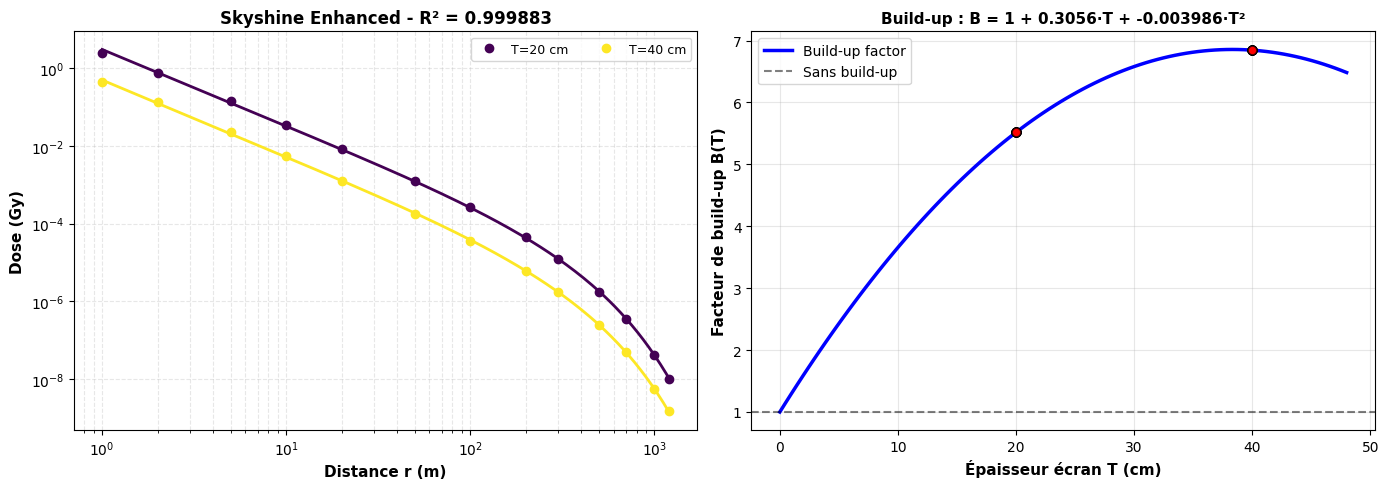

In [9]:
# Fit du modèle sur les données chargées
# Choisir le modèle selon le type de particule :
# - 'simple' pour neutrons (4 paramètres)
# - 'skyshine' pour photons (9 paramètres)

model_type = 'skyshine'  # Changez en 'simple' pour les neutrons

if model_type == 'simple':
    results = fit_simple_model(r_data, T_data, D_data, plot=True, verbose=True)
elif model_type == 'skyshine':
    results = fit_skyshine_enhanced(r_data, T_data, D_data, plot=True, verbose=True)
else:
    raise ValueError("model_type doit être 'simple' ou 'skyshine'")

## 6️⃣ Export des Paramètres

Sauvegarde des paramètres optimaux pour utilisation ultérieure.

In [11]:
if results is not None:
    # Déterminer le type de modèle utilisé
    if 'mu_screen' in results:
        # Modèle Skyshine Enhanced
        params_df = pd.DataFrame([
            {'Paramètre': 'A', 'Valeur': results['A'], 'Incertitude': results['uncertainties']['A'], 'Unité': '-'},
            {'Paramètre': 'B', 'Valeur': results['B'], 'Incertitude': results['uncertainties']['B'], 'Unité': '-'},
            {'Paramètre': 'μ_air', 'Valeur': results['mu_air'], 'Incertitude': results['uncertainties']['mu_air'], 'Unité': 'm⁻¹'},
            {'Paramètre': 'μ_sky', 'Valeur': results['mu_sky'], 'Incertitude': results['uncertainties']['mu_sky'], 'Unité': 'm⁻¹'},
            {'Paramètre': 'μ_screen', 'Valeur': results['mu_screen'], 'Incertitude': results['uncertainties']['mu_screen'], 'Unité': 'cm⁻¹'},
            {'Paramètre': 'n_sky', 'Valeur': results['n_sky'], 'Incertitude': results['uncertainties']['n_sky'], 'Unité': '-'},
            {'Paramètre': 'c₁', 'Valeur': results['c1'], 'Incertitude': results['uncertainties']['c1'], 'Unité': 'cm⁻¹'},
            {'Paramètre': 'c₂', 'Valeur': results['c2'], 'Incertitude': results['uncertainties']['c2'], 'Unité': 'cm⁻²'},
            {'Paramètre': 'f_atten', 'Valeur': results['f_atten'], 'Incertitude': results['uncertainties']['f_atten'], 'Unité': '-'},
            {'Paramètre': 'R²', 'Valeur': results['R2'], 'Incertitude': 0, 'Unité': '-'},
            {'Paramètre': 'RMSE', 'Valeur': results['RMSE'], 'Incertitude': 0, 'Unité': 'Gy'},
        ])
        filename = 'skyshine_enhanced_params.csv'
    else:
        # Modèle Simple
        params_df = pd.DataFrame([
            {'Paramètre': 'A', 'Valeur': results['A'], 'Incertitude': results['uncertainties']['A'], 'Unité': '-'},
            {'Paramètre': 'k', 'Valeur': results['k'], 'Incertitude': results['uncertainties']['k'], 'Unité': '-'},
            {'Paramètre': 'b', 'Valeur': results['b'], 'Incertitude': results['uncertainties']['b'], 'Unité': 'm⁻¹'},
            {'Paramètre': 'c', 'Valeur': results['c'], 'Incertitude': results['uncertainties']['c'], 'Unité': 'cm⁻¹'},
            {'Paramètre': 'R²', 'Valeur': results['R2'], 'Incertitude': 0, 'Unité': '-'},
            {'Paramètre': 'RMSE', 'Valeur': results['RMSE'], 'Incertitude': 0, 'Unité': 'Gy'},
        ])
        filename = 'simple_model_params.csv'
    
    # Sauvegarde
    params_df.to_csv(filename, index=False)
    print(f"\n✅ Paramètres exportés vers '{filename}'")
    
    # Affichage du tableau
    display(params_df)
else:
    print("❌ Aucun résultat à exporter")


✅ Paramètres exportés vers 'simple_model_params.csv'


,Paramètre,Valeur,Incertitude,Unité
0,A,20.838994,1.210105,-
1,k,1.925930,0.011143,-
2,b,0.004884,0.000066,m⁻¹
3,c,0.095738,0.001533,cm⁻¹
4,R²,0.999867,0.000000,-
5,RMSE,0.117669,0.000000,Gy


## 7️⃣ Fonctions de Prédiction

Utilisent les paramètres optimaux pour prédire la dose à des points arbitraires.

In [12]:
def predict_dose_simple(r, T, params):
    """
    Prédit la dose avec le modèle simple (neutrons).
    
    Parameters:
    -----------
    r : float or array
        Distance(s) en mètres
    T : float or array
        Épaisseur(s) d'écran en cm
    params : dict
        Dictionnaire des paramètres (résultat de fit_simple_model)
    
    Returns:
    --------
    D : float or array
        Dose(s) prédite(s) en Gy
    """
    r = np.asarray(r)
    T = np.asarray(T)
    
    A = params['A']
    k = params['k']
    b = params['b']
    c = params['c']
    
    return A * r**(-k) * np.exp(-b*r) * np.exp(-c*T)


def predict_dose_skyshine(r, T, params):
    """
    Prédit la dose avec le modèle Skyshine Enhanced (photons).
    
    Parameters:
    -----------
    r : float or array
        Distance(s) en mètres
    T : float or array
        Épaisseur(s) d'écran en cm
    params : dict
        Dictionnaire des paramètres (résultat de fit_skyshine_enhanced)
    
    Returns:
    --------
    D : float or array
        Dose(s) prédite(s) en Gy
    """
    r = np.asarray(r)
    T = np.asarray(T)
    
    # Extraction des paramètres
    A = params['A']
    B = params['B']
    mu_air = params['mu_air']
    mu_sky = params['mu_sky']
    mu_screen = params['mu_screen']
    n_sky = params['n_sky']
    c1 = params['c1']
    c2 = params['c2']
    f_atten = params['f_atten']
    
    # Build-up
    buildup_screen = np.maximum(1 + c1*T + c2*T**2, 0.1)
    
    # Composante directe
    D_direct = (A/r**2 * np.exp(-mu_air*r) * buildup_screen * np.exp(-mu_screen*T))
    
    # Composante skyshine
    D_skyshine = (B * r**(-n_sky) * np.exp(-mu_sky*r) * np.exp(-mu_screen*T/f_atten))
    
    return D_direct + D_skyshine


# Exemple d'utilisation
if results is not None:
    print("\n" + "="*60)
    print(" 🔮 EXEMPLES DE PRÉDICTION")
    print("="*60)
    
    examples = [
        (10, 5),    # 10 m, 5 cm
        (100, 10),  # 100 m, 10 cm
        (500, 15),  # 500 m, 15 cm
    ]
    
    # Choisir la fonction de prédiction selon le modèle
    if 'mu_screen' in results:
        predict_func = predict_dose_skyshine
        model_name = "Skyshine Enhanced"
    else:
        predict_func = predict_dose_simple
        model_name = "Simple"
    
    print(f"   Modèle : {model_name}")
    print()
    
    for r_ex, T_ex in examples:
        D_pred = predict_func(r_ex, T_ex, results)
        print(f"   r={r_ex:4.0f} m, T={T_ex:2.0f} cm  →  D = {D_pred:.6e} Gy")
    
    print("="*60)


 🔮 EXEMPLES DE PRÉDICTION
   Modèle : Simple

   r=  10 m, T= 5 cm  →  D = 1.458285e-01 Gy
   r= 100 m, T=10 cm  →  D = 6.904399e-04 Gy
   r= 500 m, T=15 cm  →  D = 2.733083e-06 Gy


---

## 📚 Résumé

Ce notebook contient **deux modèles de fit de dose** :

### 🔵 Modèle Simple (4 paramètres)
- **Formule** : $D = A \cdot r^{-k} \cdot e^{-b \cdot r} \cdot e^{-c \cdot T}$
- **Usage** : Recommandé pour les **neutrons**
- **Avantages** : Moins de paramètres, plus robuste
- **Fonction** : `fit_simple_model()` et `predict_dose_simple()`

### 🟢 Modèle Skyshine Enhanced (9 paramètres)
- **Formule** : $D = D_{\text{direct}} + D_{\text{skyshine}}$ avec build-up
- **Usage** : Optimal pour les **photons**
- **Avantages** : Capture les effets de diffusion atmosphérique
- **Fonction** : `fit_skyshine_enhanced()` et `predict_dose_skyshine()`

---

### 🎯 Utilisation recommandée

1. **Charger les données** avec la cellule de chargement
2. **Choisir le modèle** selon le type de particule :
   - `model_type = 'simple'` pour neutrons
   - `model_type = 'skyshine'` pour photons
3. **Exécuter le fit** (cellule d'application)
4. **Exporter les paramètres** en CSV
5. **Utiliser la fonction de prédiction** appropriée

**Note** : Les filtres (particule, écran, code) sont configurables dans la cellule de chargement des données.